# Diffusion Quantum Monte Carlo for Ground State Energy Estimation

## Context and Motivation

Quantum Monte Carlo (QMC) methods constitute a powerful class of stochastic techniques for solving quantum many-body problems beyond the reach of exact analytical approaches. Among these, Diffusion Quantum Monte Carlo (DMC) stands out for its ability to project out the ground state of a quantum system with controlled approximations.

The DMC method combines diffusion, branching, and population control to simulate the imaginary-time evolution of a quantum system. By tracking the statistical properties of the walker population and the evolution of $ V_{ref} $, one can extract the ground state energy and spatial distribution of the system.

## Theoretical Background

The starting point of Diffusion Quantum Monte Carlo is the time-dependent Schrödinger equation expressed in imaginary time. Under the transformation $ t \rightarrow -i\tau $, the equation becomes a diffusion-like equation with a potential-dependent source term.

In this formulation, the evolution operator exponentially suppresses higher-energy states, such that in the long-time limit ( $\tau \to \infty $), the wavefunction converges to the ground state of the system. This projection property forms the theoretical foundation of the DMC method.

The resulting equation can be interpreted probabilistically, allowing the wavefunction to be represented by a population of random walkers undergoing diffusion and branching processes.


## Objectives of the Project

The primary objective of this project is to implement a Diffusion Quantum Monte Carlo algorithm in order to estimate the ground state energy of one-dimensional quantum systems.

The project will proceed through the following steps:

- Implementation of the DMC algorithm using a population of walkers evolving in imaginary time.
- Validation of the method on the harmonic oscillator potential, for which the exact ground state energy is known.
- Analysis of statistical convergence and estimation of numerical uncertainties.
- Extension to anharmonic potentials, exploring how deviations from quadratic confinement affect the ground state energy and spatial distribution.
- Investigation of time-step errors and extrapolation to the zero time-step limit.

From a computational perspective, the project focuses on efficient handling of stochastic processes, population control mechanisms, and numerical stability.

In [216]:
import numpy as np
import matplotlib.pyplot as plt

---

## Theoretical Framework

### Imaginary Time

The imaginary time $ \tau $ is defined through the Wick rotation $ t \rightarrow -i\tau $. In this framework, the Schrödinger equation takes the form of a diffusion equation:

$$
\frac{\partial \psi(x,\tau)}{\partial \tau} = D \nabla^2 \psi(x,\tau) - (V(x) - V_{ref}) \psi(x,\tau)
$$

where $ D = \frac{1}{2} $ in the chosen system of units ($ \hbar = m = 1 $).

### Random Walkers

The wavefunction $ \psi(x,\tau) $ is represented by a discrete set of configurations called *walkers*. Each walker corresponds to a point in configuration space and evolves stochastically over time.

The dynamics of walkers consists of two processes:

- **Diffusion:** random displacements drawn from a Gaussian distribution.
- **Branching:** replication or deletion depending on the local potential energy.

### Reference Energy $ V_{ref} $

The reference energy $ V_{ref} $ is a dynamically adjusted parameter introduced to control the total number of walkers. It effectively shifts the potential and determines whether walkers are more likely to reproduce or die.

Its value is updated during the simulation to stabilize the population around a target value. In the long-time limit, $ V_{ref} $ converges to the ground state energy of the system.

### Target Population $ N_0 $

The quantity $N_0$ denotes the desired number of walkers in the simulation. Due to the stochastic nature of the branching process, the actual number of walkers fluctuates around this value.

A feedback mechanism involving $ V_{ref} $ ensures that the population remains close to $ N_0 $, preventing numerical instabilities such as exponential growth or extinction.


### Time Step $ \Delta\tau $

The imaginary time is discretized into finite steps $\Delta\tau $. The accuracy of the simulation depends on this parameter: smaller values reduce systematic errors but increase computational cost.

A careful analysis of the $ \Delta\tau \to 0 $ limit is therefore required to obtain reliable physical results.

In [217]:
N0 = 10000
dtau = 0.01

a = 1. # pour une correction de Vref stable

In [218]:
Nt = 200
N_therm = int(0.2 * Nt)

## Walker diffusion

Chaque marcheur suit :
$$x_i \leftarrow x_i + \eta, \quad \eta \sim N(0, \sqrt{\Delta \tau}) $$

la diffusion correspond au terme cinetique donc plus $\Delta \tau$ est grand plus les marcheurs s'étalent.

In [219]:
def diffuse(walkers : np.ndarray, dtau : float) -> np.ndarray :
  return walkers + np.random.normal(0, np.sqrt(dtau), size=walkers.shape)

---

## Potentiel

L'on va utiliser dans notre simulation plusieur potentiel :

### Harmonic

$$V(x) = \frac{1}{2} x^2$$

- $E_0 = \frac 1 2$
- $\psi_{harm} \propto e^{-x^2/2}$

### Anharmonique Cubique
$$V(x) = \frac{1}{2} x^2 + bx^3$$

- $E_0 = \frac 1 2 - \frac{11} 8 b^2$
- $\psi_{cub} \propto \psi_{harm} - b(\frac 1 {\sqrt 2} \psi_1(x) + \frac 1{\sqrt{48}}\psi_3(x))$

with $\psi_1 \propto xe^{-x^2/2}$ and $\psi_3 \propto (8x^3-12x)e^{-x^2/2}$.

### Anharmonique Quartic
$$V(x) = \frac{1}{2} x^2 + bx^4$$

- $E_0 = \frac 1 2 + \frac{3} 4 b- \frac{21} 8 b^2$
- $\psi_{quart} \propto \psi_{harm} - b(\frac 3 {2 \sqrt 2} \psi_2(x) + \frac {\sqrt 6}{8}\psi_3(x))$

with $\psi_2 \propto (4x^2-2)e^{-x^2/2}$ and $\psi_3 \propto (16x^4-48x^2+12)e^{-x^2/2}$.


In [220]:
b = 0.1
# Potential
def V(x, kind:str="Harmonic", b:float=0.1):
    if kind == "Harmonic":
        return 0.5 * x**2
    elif kind == "Anharmonic Cubic":
        return 0.5 * x**2 + b * x**3
    elif kind == "Anharmonic Quartic":
        return 0.5 * x**2 + b * x**4

# Theoric value
V_list = ["Harmonic", "Anharmonic Cubic", "Anharmonic Quartic"]

## energy
E0_list = [0.5, 1/2-(11*(b**2)/8), 1/2+((3*b)/4)-((21*(b**2))/8)]
E0_theoric = {}
for potential_name, E0 in zip(V_list, E0_list):
  E0_theoric[potential_name] = E0

## states
psi0_list = []
x = np.linspace(-3, 3, 200)

### Harmonique
psi_harm = np.exp(-x**2/2)
psi_harm /= np.trapezoid(psi_harm, x)
psi0_list.append(psi_harm)

### Anharmonique Cubique
psi1 = x * psi_harm
psi1 /= np.trapezoid(psi1, x)

psi3 = (8*x**3 - 12*x) * psi_harm
psi3 /= np.trapezoid(psi3, x)

psi_cub = psi_harm - b*(1/np.sqrt(2) * psi1 + 1/np.sqrt(48) * psi3)
psi_cub /= np.trapezoid(psi_cub, x)
psi0_list.append(psi_cub)

### Anharmonique Quartic
psi2 = (4*x**2 - 2) * psi_harm
psi2 /= np.trapezoid(psi2, x)

psi4 = (16*x**4 - 48*x**2 + 12) * psi_harm
psi4 /= np.trapezoid(psi4, x)

psi_quart = psi_harm - b*(3/(2*np.sqrt(2)) * psi2 + np.sqrt(6)/8 * psi3)
psi_quart /= np.trapezoid(psi_quart, x)
psi0_list.append(psi_quart)

### dict of all
psi0_theoric = {}
for potential_name, psi0 in zip(V_list, psi0_list):
  psi0_theoric[potential_name] = psi0

---

## Branching

Chaque marcheur a un poids :

$$w_i = e^{-(V(x_i)-V_{ref})\Delta \tau}$$

- $w_i > 1 \rightarrow$ reproduction
- $w_i < 1 \rightarrow$ disparition probable

Pour chaque marcheur, on va :
- calculer $w_i$ et $n_i=⌊w_i⌋$,
- tirer un random $r \in [0,1]$,
- si $r < (w_i - n_i)$ on ajoute une copie de ce walker.


In [221]:
def branch(walkers : np.ndarray, Vref : float, dtau : float, potential:str="Harmonic") -> np.ndarray:
    w = np.exp(-(V(walkers, potential) - Vref) * dtau) # par defaut V(x) = oscilateur harmonique
    n = np.floor(w).astype(int)

    diff = w - n
    r = np.random.rand(len(walkers))
    extra = (r < diff).astype(int)

    copies = n + extra
    return np.repeat(walkers, copies)

---

## Update $V_{ref}$

Pour eviter que le nombre de walkers n'explose ou ne s'eteigne, on va modifier la valeur de $V_{ref}$

$$V_{ref} = \langle V \rangle - \frac{a}{N_0 \Delta \tau}(N-N_0)$$

avec : $ \langle V \rangle = \frac 1 N \sum_i V(x_i) $

Avec cela si :
- $N>N_0$ alors $V_{ref} \nearrow$ moin de walker
- $N<N_0$ alors $V_{ref} \searrow$ plus de walker

Cela nous permet d'avoir a l'equilibre :
$$N \approx N_0 \implies V_{ref} \approx \langle V \rangle \approx E_0$$

Car $V_{ref}$ joue le role de $E_0$ dans
$$\psi(x,\tau) \sim e^{-(H-E_0)\tau}$$

la moyenne de $V_{ref}$ devrait donc donner l'énergie fondamentale $E_0$.

In [222]:
def update_Vref(walkers : np.ndarray, N0 :int, dtau : float, potential:str="Harmonic", a : float=1.) -> float:
  N = len(walkers)
  Vmean = np.mean(V(walkers, potential))
  correction = (a*(N-N0))/(N0 * dtau)
  return Vmean - correction

---

##

In [223]:
N_list, Vref_list = {}, {}
all_walkers = {}

for potential_name in V_list :
  walkers = np.random.normal(0, 1, size=N0) # positions x_i
  Vref = np.mean(V(walkers, potential_name))

  N_temp, Vref_temp = [], []
  all_walkers_temp = []

  for t in range(Nt):
    walkers = diffuse(walkers, dtau)
    walkers = branch(walkers, Vref, dtau, potential_name)

    Vref = update_Vref(walkers, N0, dtau, potential_name, a)

    if t > N_therm:
      all_walkers_temp.extend(walkers)

    # result
    Vref_temp.append(Vref)
    N_temp.append(len(walkers))

  N_list[potential_name] = N_temp
  Vref_list[potential_name] = Vref_temp
  all_walkers[potential_name] = all_walkers_temp

--------------------
Potential Harmonic :


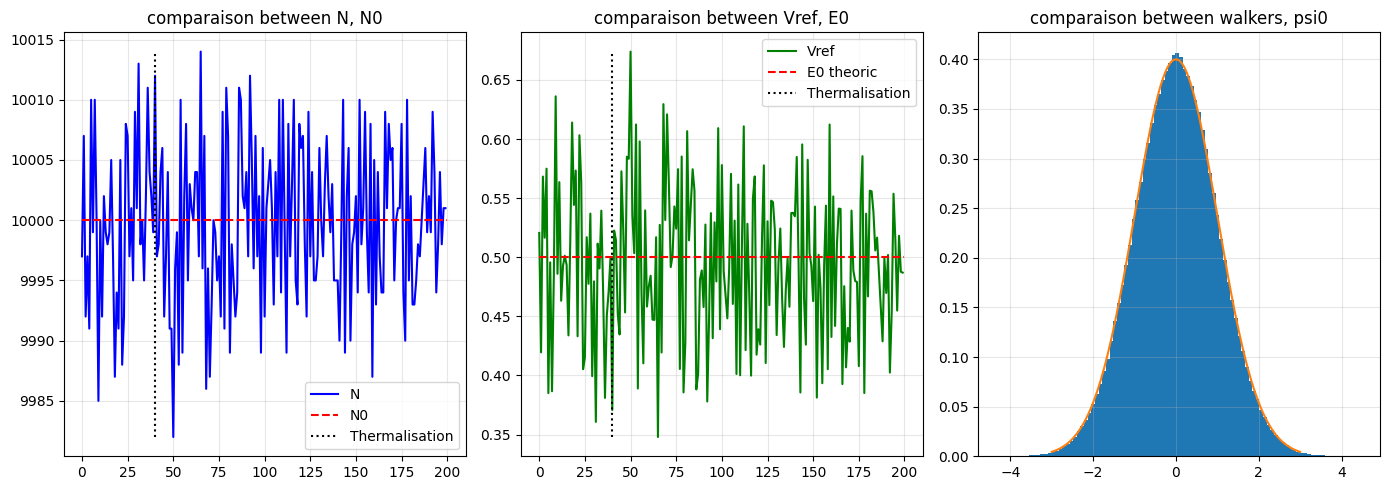

E0 numeric = 0.49430796522668247 ± 0.005104385752712915
error : 0.005692034773317534
--------------------
Potential Anharmonic Cubic :


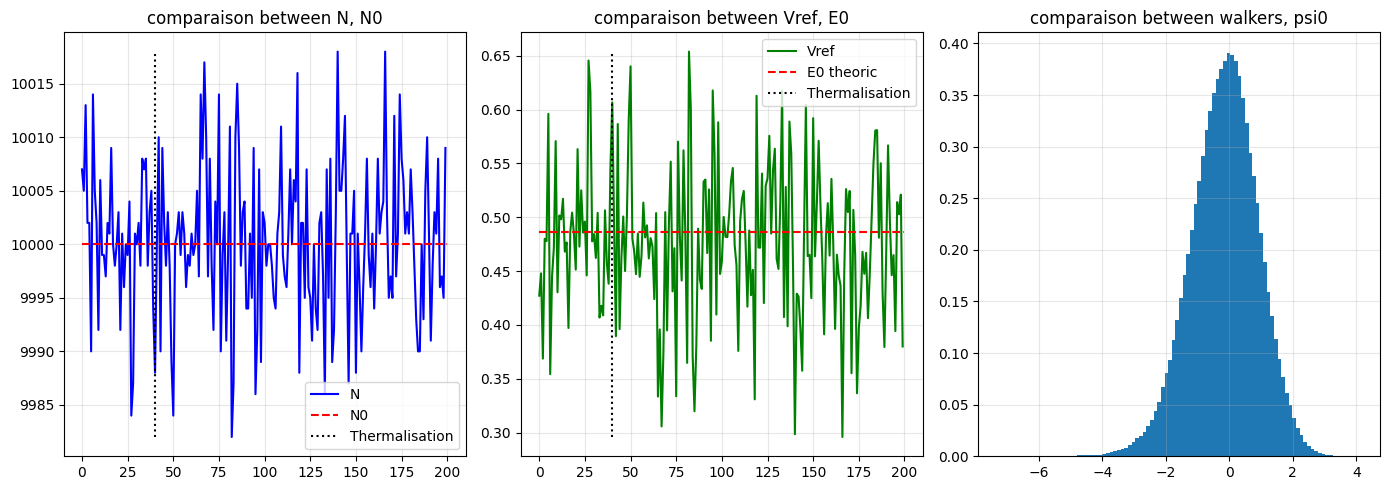

E0 numeric = 0.47522333090588653 ± 0.005698155118357495
error : 0.011026669094113484
--------------------
Potential Anharmonic Quartic :


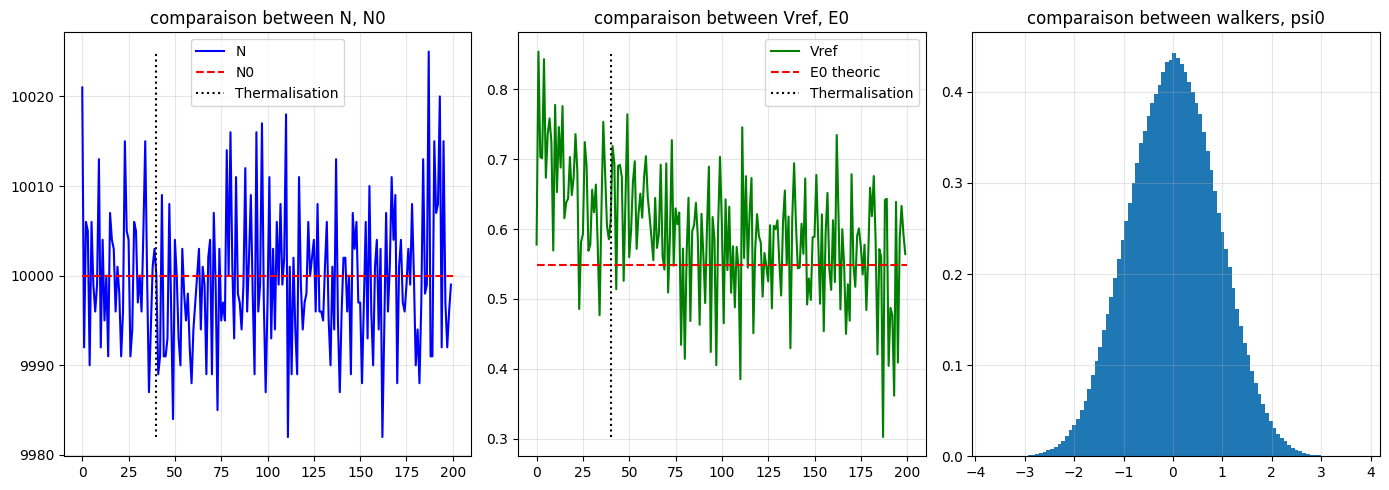

E0 numeric = 0.5778045578693499 ± 0.006461832664760736
error : 0.029054557869349962


In [224]:
for potential_name in V_list:
  print("--------------------\nPotential", potential_name, ":")

  fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

  N_potential = N_list[potential_name]
  Vref_potential = Vref_list[potential_name]

  ax1.plot(N_potential, color='blue', label='N')
  ax1.hlines(N0, xmin=0, xmax=Nt, colors='red', linestyles='--', label='N0')
  ax1.vlines(N_therm, ymin=min(N_potential), ymax=max(N_potential), colors='black', linestyles=':', label='Thermalisation')
  ax1.set_title("comparaison between N, N0")
  ax1.grid(True, alpha=0.3)
  ax1.legend()

  ax2.plot(Vref_potential, color='green', label='Vref')
  ax2.hlines(E0_theoric[potential_name], xmin=0, xmax=Nt, colors='red', linestyles='--', label='E0 theoric')
  ax2.vlines(N_therm, ymin=min(Vref_potential), ymax=max(Vref_potential), colors='black', linestyles=':', label='Thermalisation')
  ax2.set_title("comparaison between Vref, E0")
  ax2.grid(True, alpha=0.3)
  ax2.legend()

  ax3.hist(all_walkers[potential_name], bins=100, density=True)
  if potential_name == "Harmonic":
    ax3.plot(x, psi0_theoric[potential_name])
  ax3.grid(True, alpha=0.3)
  ax3.set_title("comparaison between walkers, psi0")

  #titre de la figure "Potential"+ potential_name + ":"
  plt.tight_layout()
  plt.show()

  E0 = np.mean(Vref_potential[N_therm:])
  error = np.std(Vref_potential[N_therm:]) / np.sqrt(len(Vref_potential[N_therm:]))
  print(f"E0 numeric = {E0} ± {error}")
  print(f"error : {np.abs(E0-E0_theoric[potential_name])}")


